<a href="https://colab.research.google.com/github/poonam-021/explainable-ai-stress-burnout/blob/main/models/Visual_Analysis_Of_Stress.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CORE TRAINING PIPELINE

In [ ]:
import os           # For navigating folders and file paths
import random       # Python's built-in random number generator

# --- Data & Math ---
import numpy as np          # Arrays, matrix math, pixel manipulation
import pandas as pd         # DataFrames — used heavily for CK+ CSV

# --- Image processing ---
import cv2                  # OpenCV: reading, resizing, colour conversion

# --- Visualisation ---
import matplotlib.pyplot as plt   # Plotting images, charts, curves
import matplotlib.patches as mpatches  # For custom legend patches
import seaborn as sns              # Beautiful statistical plots

# --- Progress bars (so long loops don't feel like they froze) ---
from tqdm import tqdm

# --- Path handling (cleaner than raw strings) ---
from pathlib import Path

# --- TensorFlow / Keras (our deep learning framework) ---
import tensorflow as tf
from tensorflow import keras

# --- Collections (for counting) ---
from collections import Counter

# ── Fix ALL random seeds so results are 100% reproducible ───
SEED = 42
random.seed(SEED)                          # Python random
np.random.seed(SEED)                       # NumPy random
tf.random.set_seed(SEED)                   # TensorFlow random
os.environ['PYTHONHASHSEED'] = str(SEED)   # Hash-based randomness in Python

# ── Print versions so we know our environment ───────────────
print("=" * 55)
print("  ✅  All imports loaded successfully!")
print("=" * 55)
print(f"  NumPy     : {np.__version__}")
print(f"  Pandas    : {pd.__version__}")
print(f"  OpenCV    : {cv2.__version__}")
print(f"  TensorFlow: {tf.__version__}")
print(f"  GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("=" * 55)
import os           # For navigating folders and file paths
import random       # Python's built-in random number generator

# --- Data & Math ---
import numpy as np          # Arrays, matrix math, pixel manipulation
import pandas as pd         # DataFrames — used heavily for CK+ CSV

# --- Image processing ---
import cv2                  # OpenCV: reading, resizing, colour conversion

# --- Visualisation ---
import matplotlib.pyplot as plt   # Plotting images, charts, curves
import matplotlib.patches as mpatches  # For custom legend patches
import seaborn as sns              # Beautiful statistical plots

# --- Progress bars (so long loops don't feel like they froze) ---
from tqdm import tqdm

# --- Path handling (cleaner than raw strings) ---
from pathlib import Path

# --- TensorFlow / Keras (our deep learning framework) ---
import tensorflow as tf
from tensorflow import keras

# --- Collections (for counting) ---
from collections import Counter

# ── Fix ALL random seeds so results are 100% reproducible ───
SEED = 42
random.seed(SEED)                          # Python random
np.random.seed(SEED)                       # NumPy random
tf.random.set_seed(SEED)                   # TensorFlow random
os.environ['PYTHONHASHSEED'] = str(SEED)   # Hash-based randomness in Python

print("=" * 55)
print("  ✅  All imports loaded successfully!")
print("=" * 55)
print(f"  NumPy     : {np.__version__}")
print(f"  Pandas    : {pd.__version__}")
print(f"  OpenCV    : {cv2.__version__}")
print(f"  TensorFlow: {tf.__version__}")
print(f"  GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("=" * 55)


  ✅  All imports loaded successfully!
  NumPy     : 2.0.2
  Pandas    : 2.2.2
  OpenCV    : 4.13.0
  TensorFlow: 2.19.0
  GPU available: False
  ✅  All imports loaded successfully!
  NumPy     : 2.0.2
  Pandas    : 2.2.2
  OpenCV    : 4.13.0
  TensorFlow: 2.19.0
  GPU available: False


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Copy zip from Drive to Colab's fast local disk
!cp /content/drive/MyDrive/raf-db.zip /content/

# Unzip quietly (-q) into a dedicated folder (-d)
!unzip -q /content/raf-db.zip -d /content/raf_data/

print("✅  RAF-DB extracted to /content/raf_data/")

✅  RAF-DB extracted to /content/raf_data/


In [ ]:
!cp /content/drive/MyDrive/ck+.zip /content/
!unzip -q /content/ck+.zip -d /content/cf_data/

print("✅  CK+ extracted to /content/cf_data/")

✅  CK+ extracted to /content/cf_data/


In [ ]:
#RAF-DB paths
RAF_TRAIN_DIR = Path('/content/raf_data/raf-db/train')  # 7 emotion folders
RAF_TEST_DIR  = Path('/content/raf_data/raf-db/test')   # same structure


In [ ]:
#CK+ path
CK_CSV_PATH = Path('/content/cf_data/ck+/ckextended.csv')

In [ ]:
# ── Target image size (EfficientNetV2-S expects 224×224×3) ───
IMG_SIZE = 224      # Both height and width
IMG_CHANNELS = 3    # RGB (3 colour channels)

In [ ]:
STRESS    = 1       # Label for stressed images
NO_STRESS = 0       # Label for non-stressed images

In [ ]:
#RAF-DB emotion label mapping
# Folder number (as a string) → emotion name → binary label
# We store the name too so our EDA prints are readable
RAF_EMOTION_NAMES = {
    '1': 'Surprise',   # → No-Stress
    '2': 'Fear',       # → Stress
    '3': 'Disgust',    # → Stress
    '4': 'Happy',      # → No-Stress
    '5': 'Sad',        # → Stress
    '6': 'Anger',      # → Stress
    '7': 'Neutral',    # → No-Stress
}

# Set of folder numbers that map to STRESS=1
RAF_STRESS_FOLDERS = {'2', '3', '5', '6'}   # Fear, Disgust, Sad, Anger


In [ ]:
#CK+ emotion label mapping
# CK+ uses DIFFERENT numbers than RAF-DB
CK_EMOTION_NAMES = {
    0: 'Anger',      # → Stress
    1: 'Contempt',   # → Discard (ambiguous, not used)
    2: 'Disgust',    # → Stress
    3: 'Fear',       # → Stress
    4: 'Happy',      # → No-Stress
    5: 'Sadness',    # → Stress
    6: 'Surprise',   # → No-Stress
    7: 'Neutral',    # → No-Stress
}

# CK+ emotion integers that are stress-related
CK_STRESS_EMOTIONS = {0, 2, 3, 5}    # Anger, Disgust, Fear, Sadness


In [ ]:
#Training constants
BATCH_SIZE    = 32     # Images per training step
EPOCHS_STAGE1 = 10     # Frozen backbone training
EPOCHS_STAGE2 = 20     # Fine-tuning training
LEARNING_RATE = 1e-3   # Initial learning rate

In [ ]:
paths_to_check = {
    "RAF Train Dir" : RAF_TRAIN_DIR,
    "RAF Test Dir"  : RAF_TEST_DIR,
    "CK+ CSV"       : CK_CSV_PATH,
}

In [ ]:
all_ok = True
for name, path in paths_to_check.items():
    exists = path.exists()
    status = "✅" if exists else "❌  NOT FOUND"
    print(f"  {status}  {name}: {path}")
    if not exists:
        all_ok = False

print("=" * 55)
if all_ok:
    print("  ✅  All paths verified. Ready to proceed!")
else:
    print("  ❌  Fix the missing paths above before continuing.")

  ✅  RAF Train Dir: /content/raf_data/raf-db/train
  ✅  RAF Test Dir: /content/raf_data/raf-db/test
  ✅  CK+ CSV: /content/cf_data/ck+/ckextended.csv
  ✅  All paths verified. Ready to proceed!


In [ ]:
print("📊  EDA — RAF-DB DATASET ANALYSIS")

📊  EDA — RAF-DB DATASET ANALYSIS


In [ ]:
#We'll build a list of dicts, then make a DataFrame.
#it iterate through train/test splits, count images per emotion folder, maps them to emotion names and binary stress labels

#list to hold dictionaries.. one per folder/split combo
raf_stats = []

for split_name, split_dir in [("Train", RAF_TRAIN_DIR), ("Test", RAF_TEST_DIR)]:

    for folder_num in sorted(os.listdir(split_dir)):  # '1','2',...,'7' (sorted alphabetically)

        folder_path = split_dir / folder_num #builds a full path using '/'

        # Skip if it's not a folder (e.g., hidden files like .DS_Store)
        if not folder_path.is_dir():
            continue

        # Count only image files (jpg, jpeg, png — case insensitive)
        image_files = [
            f for f in folder_path.iterdir()
            if f.suffix.lower() in ['.jpg', '.jpeg', '.png']
        ]
        count = len(image_files)

        # Get emotion name from our mapping
        emotion_name = RAF_EMOTION_NAMES.get(folder_num, 'Unknown')

        # Determine binary label
        binary_label = STRESS if folder_num in RAF_STRESS_FOLDERS else NO_STRESS
        label_name   = "STRESS" if binary_label == STRESS else "NO-STRESS"

        # Append a dictionary — each becomes one row in the DataFrame
        raf_stats.append({
            'Split'        : split_name,
            'Folder'       : folder_num,
            'Emotion'      : emotion_name,
            'Image Count'  : count,
            'Binary Label' : binary_label,
            'Label Name'   : label_name,
        })


In [ ]:
#Create a Pandas DataFrame from our list of dicts
raf_df = pd.DataFrame(raf_stats)

In [ ]:
print(raf_df.head())

   Split Folder   Emotion  Image Count  Binary Label Label Name
0  Train      1  Surprise         1290             0  NO-STRESS
1  Train      2      Fear          281             1     STRESS
2  Train      3   Disgust          717             1     STRESS
3  Train      4     Happy         4772             0  NO-STRESS
4  Train      5       Sad         1982             1     STRESS


In [ ]:
print(raf_df.tail())


   Split Folder  Emotion  Image Count  Binary Label Label Name
9   Test      3  Disgust          160             1     STRESS
10  Test      4    Happy         1185             0  NO-STRESS
11  Test      5      Sad          478             1     STRESS
12  Test      6    Anger          162             1     STRESS
13  Test      7  Neutral          680             0  NO-STRESS


In [ ]:
print(raf_df.groupby('Split')['Image Count'].sum())  # Total images per split


Split
Test      3068
Train    12271
Name: Image Count, dtype: int64


In [ ]:
print(f"{raf_df.shape[0]} rows, {raf_df.shape[1]} columns")

14 rows, 6 columns


In [ ]:
print(raf_df.dtypes)

Split           object
Folder          object
Emotion         object
Image Count      int64
Binary Label     int64
Label Name      object
dtype: object


In [ ]:
print(raf_df.isnull().sum())


Split           0
Folder          0
Emotion         0
Image Count     0
Binary Label    0
Label Name      0
dtype: int64


In [ ]:
print(raf_df.describe())


       Image Count  Binary Label
count    14.000000     14.000000
mean   1095.642857      0.571429
std    1279.412822      0.513553
min      74.000000      0.000000
25%     293.000000      0.000000
50%     692.500000      1.000000
75%    1263.750000      1.000000
max    4772.000000      1.000000


In [ ]:
grouped = raf_df.groupby(['Split', 'Label Name'])['Image Count'].sum().reset_index()
print(grouped)

   Split Label Name  Image Count
0   Test  NO-STRESS         2194
1   Test     STRESS          874
2  Train  NO-STRESS         8586
3  Train     STRESS         3685


In [ ]:
# EDA- visualize RAF-DB distributions

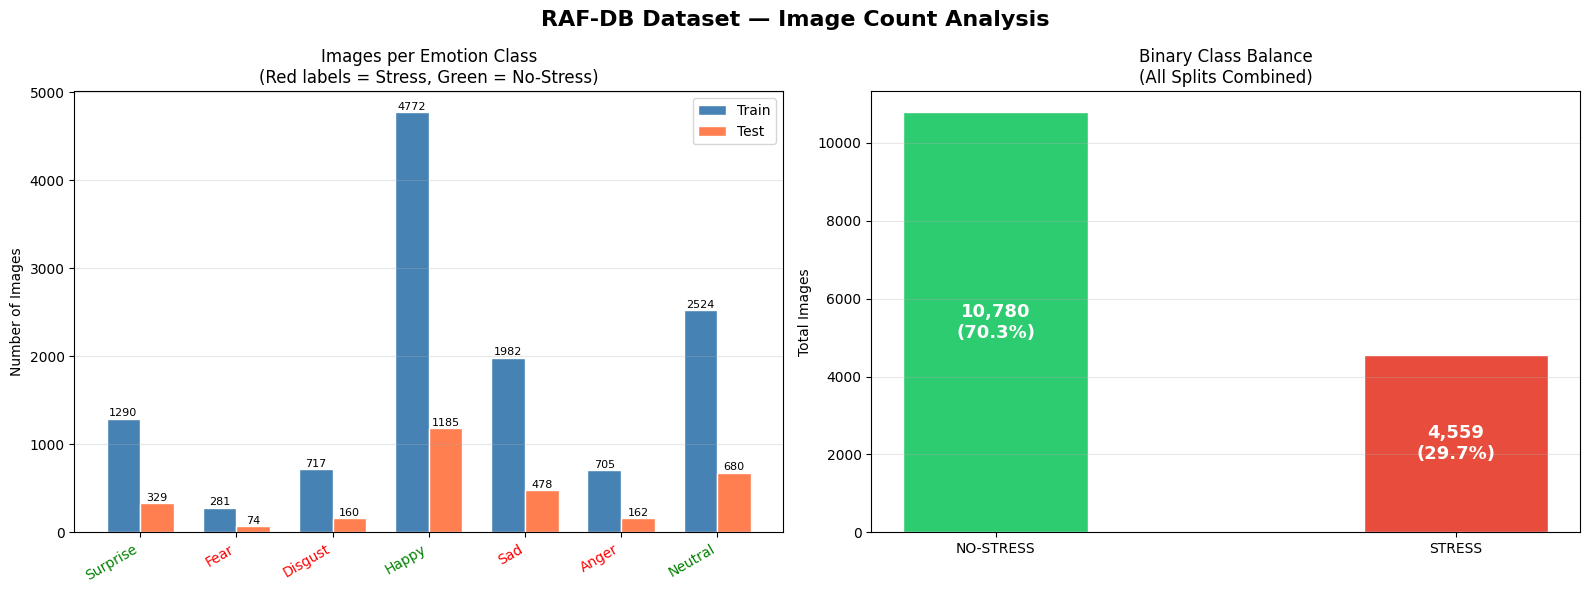

✅  RAF-DB distribution chart saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RAF-DB Dataset — Image Count Analysis', fontsize=16, fontweight='bold')

# ── Plot 1: Per-emotion count (stacked by train/test) ────────
train_data = raf_df[raf_df['Split'] == 'Train'].set_index('Emotion')['Image Count']
test_data  = raf_df[raf_df['Split'] == 'Test'].set_index('Emotion')['Image Count']

emotions = [RAF_EMOTION_NAMES[str(i)] for i in range(1, 8)]

x = np.arange(len(emotions))
width = 0.35

bars1 = axes[0].bar(x - width/2, [train_data.get(e, 0) for e in emotions],
                    width, label='Train', color='steelblue', edgecolor='white')
bars2 = axes[0].bar(x + width/2, [test_data.get(e, 0) for e in emotions],
                    width, label='Test',  color='coral',     edgecolor='white')

# Colour the x-tick labels by stress/no-stress
tick_colours = ['red' if RAF_EMOTION_NAMES[str(i)] in
                [RAF_EMOTION_NAMES[k] for k in RAF_STRESS_FOLDERS] else 'green'
                for i in range(1, 8)]

axes[0].set_xticks(x)
axes[0].set_xticklabels(emotions, rotation=30, ha='right')
for tick, colour in zip(axes[0].get_xticklabels(), tick_colours):
    tick.set_color(colour)

axes[0].set_title('Images per Emotion Class\n(Red labels = Stress, Green = No-Stress)',
                  fontsize=12)
axes[0].set_ylabel('Number of Images')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add count labels on top of bars
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 5,
                 str(int(h)), ha='center', va='bottom', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 5,
                 str(int(h)), ha='center', va='bottom', fontsize=8)

# ── Plot 2: Binary class balance (Stress vs No-Stress) ───────
binary_totals = raf_df.groupby('Label Name')['Image Count'].sum()

colours = ['#e74c3c' if lbl == 'STRESS' else '#2ecc71'
           for lbl in binary_totals.index]

bars3 = axes[1].bar(binary_totals.index, binary_totals.values,
                    color=colours, edgecolor='white', width=0.4)

# Add percentage labels inside bars
total_imgs = binary_totals.sum()
for bar, val in zip(bars3, binary_totals.values):
    pct = val / total_imgs * 100
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() / 2,
                 f'{val:,}\n({pct:.1f}%)',
                 ha='center', va='center',
                 fontsize=13, fontweight='bold', color='white')

axes[1].set_title('Binary Class Balance\n(All Splits Combined)', fontsize=12)
axes[1].set_ylabel('Total Images')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/raf_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  RAF-DB distribution chart saved!")


In [ ]:
print("  📊  EDA — CK+ DATASET CSV ANALYSIS")


  📊  EDA — CK+ DATASET CSV ANALYSIS


In [ ]:
ck_df = pd.read_csv(CK_CSV_PATH)


In [ ]:
print(ck_df.shape)

(920, 3)


In [ ]:
print(list(ck_df.columns))


['emotion', 'pixels', 'Usage']


In [ ]:
print(ck_df.head())


   emotion                                             pixels     Usage
0        6  36 39 35 25 19 11 8 7 3 13 15 9 21 57 75 90 10...  Training
1        6  88 74 19 4 5 5 3 12 8 21 15 21 15 18 24 29 32 ...  Training
2        6  9 2 4 7 1 1 1 0 7 29 49 76 115 141 156 169 177...  Training
3        6  104 106 108 104 95 50 60 61 58 83 126 133 139 ...  Training
4        6  68 72 67 67 6 2 1 1 1 1 1 14 24 24 38 65 79 94...  Training


In [ ]:
print(ck_df.tail())


     emotion                                             pixels        Usage
915        5  87 86 88 92 92 127 231 248 251 253 254 254 254...  PrivateTest
916        5  21 24 26 28 27 28 30 8 0 0 0 0 0 0 1 4 37 42 4...  PrivateTest
917        5  76 40 31 38 28 34 38 36 41 36 46 38 44 26 45 5...  PrivateTest
918        5  114 87 16 29 17 25 30 34 37 35 45 93 63 80 73 ...  PrivateTest
919        5  101 102 99 96 98 42 23 18 15 17 27 34 17 24 29...  PrivateTest


In [ ]:
print(ck_df.dtypes)


emotion     int64
pixels     object
Usage      object
dtype: object


In [ ]:
missing = ck_df.isnull().sum()
print(missing)


emotion    0
pixels     0
Usage      0
dtype: int64


In [ ]:
total_missing = ck_df.isnull().sum().sum()
if total_missing == 0:
    print("No missing values — clean dataset!")
else:
    print(f"{total_missing} missing values found — will drop them.")


No missing values — clean dataset!


In [ ]:
print(ck_df.describe())


          emotion
count  920.000000
mean     4.920652
std      1.882630
min      0.000000
25%      5.000000
50%      6.000000
75%      6.000000
max      7.000000


In [ ]:
ck_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  920 non-null    int64 
 1   pixels   920 non-null    object
 2   Usage    920 non-null    object
dtypes: int64(1), object(2)
memory usage: 21.7+ KB


In [ ]:
print(ck_df['Usage'].unique())


['Training' 'PublicTest' 'PrivateTest']


In [ ]:
print(ck_df['Usage'].value_counts())


Usage
Training       734
PrivateTest     95
PublicTest      91
Name: count, dtype: int64


In [ ]:
emotion_counts = ck_df['emotion'].value_counts().sort_index()
print(emotion_counts)

emotion
0     45
1     59
2     25
3     69
4     28
5     83
6    593
7     18
Name: count, dtype: int64


In [ ]:
emotion_count_df = pd.DataFrame({
    'Emotion Code' : emotion_counts.index,
    'Emotion Name' : [CK_EMOTION_NAMES.get(i, 'Unknown') for i in emotion_counts.index],
    'Frame Count'  : emotion_counts.values,
    'Stress Label' : ['STRESS' if i in CK_STRESS_EMOTIONS else 'NO-STRESS'
                      for i in emotion_counts.index],
})
print("\n📋  Emotion table with labels:")
print(emotion_count_df.to_string(index=False))


📋  Emotion table with labels:
 Emotion Code Emotion Name  Frame Count Stress Label
            0        Anger           45       STRESS
            1     Contempt           59    NO-STRESS
            2      Disgust           25       STRESS
            3         Fear           69       STRESS
            4        Happy           28    NO-STRESS
            5      Sadness           83       STRESS
            6     Surprise          593    NO-STRESS
            7      Neutral           18    NO-STRESS


In [ ]:
# we dont print the large pixel values instead just the emotion label i.e metadata columns you want to inspect
cols_to_show = [c for c in ck_df.columns if c != 'pixels']
print(ck_df[cols_to_show].sample(3, random_state=SEED))

     emotion        Usage
319        6     Training
377        6     Training
538        6  PrivateTest


In [ ]:
print("\n Pixel string format check:")

# we get first row's pixel string i.e 2404 space seperated integers (0-255 range)
sample_pixel_str = ck_df['pixels'].iloc[0]

# convert into list form. splitting by space
#each value = one pixel intensity (grayscale)
pixel_values     = sample_pixel_str.split(' ')

print(f"Pixel string length (chars): {len(sample_pixel_str)}") #pixel string length that has spaces too (before splitting)
print(f"Number of pixel values     : {len(pixel_values)}")
print(f"First 10 pixel values      : {pixel_values[:10]}")
print(f"Expected: 48×48 = 2304 pixel values → Got: {len(pixel_values)}")


 Pixel string format check:
Pixel string length (chars): 8036
Number of pixel values     : 2304
First 10 pixel values      : ['36', '39', '35', '25', '19', '11', '8', '7', '3', '13']
Expected: 48×48 = 2304 pixel values → Got: 2304


In [ ]:
if len(pixel_values) == 2304:
    print("Pixel format is correct (48×48 = 2304 values)")
else:
    print("Unexpected pixel count! Check the CSV.")

Pixel format is correct (48×48 = 2304 values)


In [ ]:
#Filter to only rows with valid emotion numbers
valid_emotions = set(CK_EMOTION_NAMES.keys())          # 0 through 7
invalid_rows   = ck_df[~ck_df['emotion'].isin(valid_emotions)]
print(f"\nRows with invalid emotion codes: {len(invalid_rows)}")


Rows with invalid emotion codes: 0


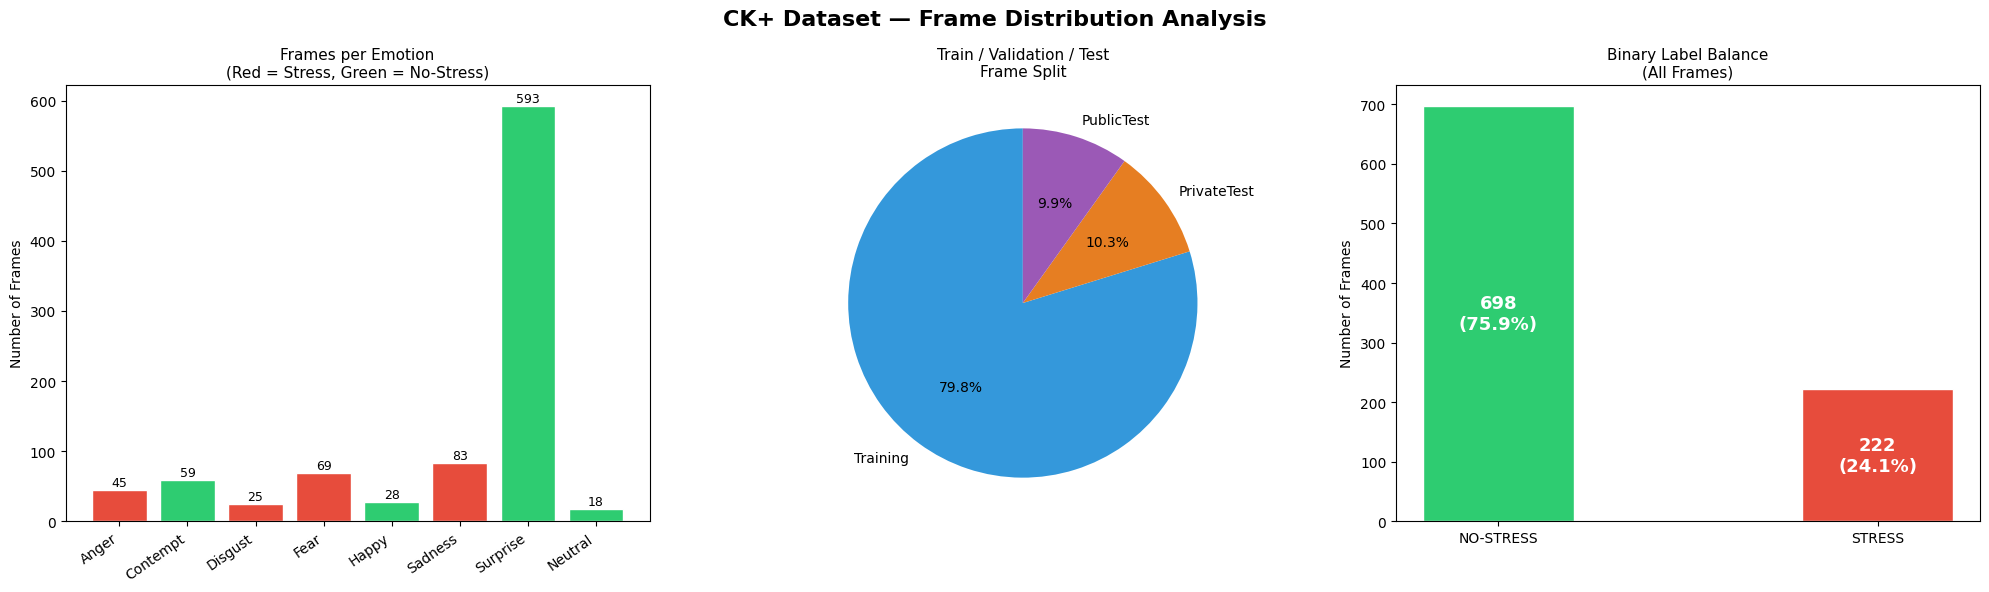

✅  CK+ distribution chart saved!


In [ ]:
# EDA VISUALIZATION FOR CK+ DISTRIBUTIONS

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('CK+ Dataset — Frame Distribution Analysis', fontsize=16, fontweight='bold')

# Plot 1: Frame count per emotion
emotion_names_list = [CK_EMOTION_NAMES[i] for i in sorted(emotion_counts.index)]
frame_counts_list  = [emotion_counts[i]   for i in sorted(emotion_counts.index)]

bar_colours = ['#e74c3c' if i in CK_STRESS_EMOTIONS else '#2ecc71'
               for i in sorted(emotion_counts.index)]

bars = axes[0].bar(emotion_names_list, frame_counts_list, color=bar_colours, edgecolor='white')
axes[0].set_title('Frames per Emotion\n(Red = Stress, Green = No-Stress)', fontsize=11)
axes[0].set_ylabel('Number of Frames')

# FIXED: Set ticks FIRST, then labels
axes[0].set_xticks(range(len(emotion_names_list)))
axes[0].set_xticklabels(emotion_names_list, rotation=35, ha='right')

for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 1,
                 str(int(bar.get_height())),
                 ha='center', va='bottom', fontsize=9)

# Plot 2: Train vs Test split
usage_counts = ck_df['Usage'].value_counts()
axes[1].pie(usage_counts.values,
            labels=usage_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=['#3498db', '#e67e22', '#9b59b6'])
axes[1].set_title('Train / Validation / Test\nFrame Split', fontsize=11)

# Plot 3: Binary Stress vs No-Stress balance
stress_count    = ck_df[ck_df['emotion'].isin(CK_STRESS_EMOTIONS)].shape[0]
no_stress_count = ck_df[~ck_df['emotion'].isin(CK_STRESS_EMOTIONS)].shape[0]

axes[2].bar(['NO-STRESS', 'STRESS'],
            [no_stress_count, stress_count],
            color=['#2ecc71', '#e74c3c'],
            edgecolor='white', width=0.4)

total = stress_count + no_stress_count
for i, (label, val) in enumerate(zip(['NO-STRESS', 'STRESS'],
                                      [no_stress_count, stress_count])):
    axes[2].text(i, val / 2,
                 f'{val:,}\n({val/total*100:.1f}%)',
                 ha='center', va='center',
                 fontsize=13, fontweight='bold', color='white')

axes[2].set_title('Binary Label Balance\n(All Frames)', fontsize=11)
axes[2].set_ylabel('Number of Frames')

plt.tight_layout()
plt.savefig('/content/ckplus_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  CK+ distribution chart saved!")


Preparing RAF-DB sample image grid...


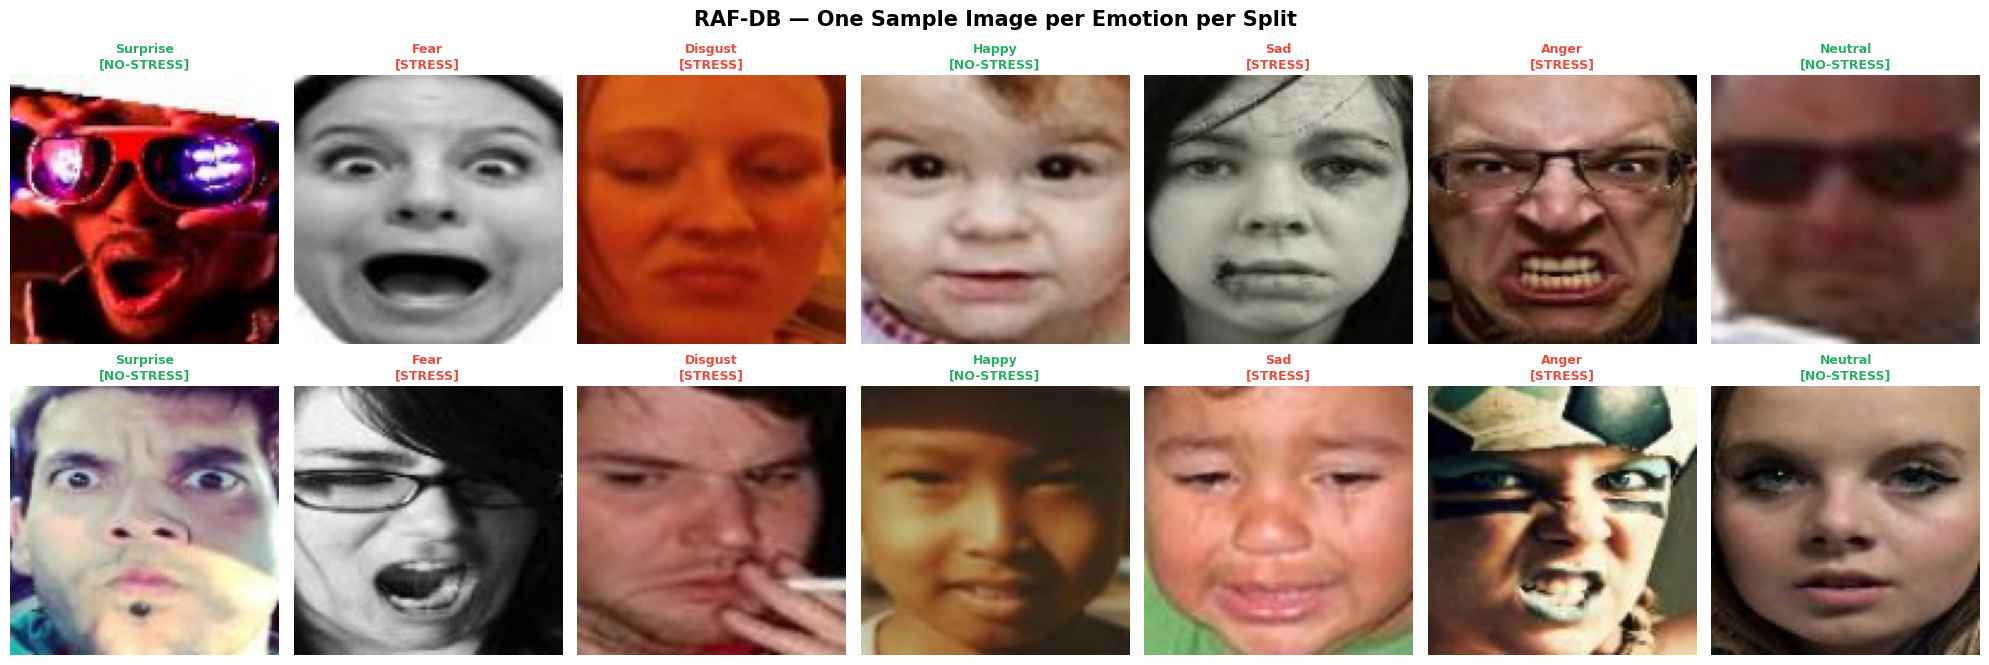

✅  RAF-DB sample grid saved!


In [ ]:
print("Preparing RAF-DB sample image grid...")

fig, axes = plt.subplots(2, 7, figsize=(20, 7))
fig.suptitle('RAF-DB — One Sample Image per Emotion per Split',
             fontsize=15, fontweight='bold')

for row_idx, (split_name, split_dir) in enumerate([("Train", RAF_TRAIN_DIR),
                                                    ("Test",  RAF_TEST_DIR)]):
    for col_idx, folder_num in enumerate(['1','2','3','4','5','6','7']):

        folder_path = split_dir / folder_num
        emotion     = RAF_EMOTION_NAMES[folder_num]
        is_stress   = folder_num in RAF_STRESS_FOLDERS

        ax = axes[row_idx][col_idx]

        # Find the first valid image in this folder
        image_files = list(folder_path.glob('*.jpg')) + \
                      list(folder_path.glob('*.jpeg')) + \
                      list(folder_path.glob('*.png'))

        if len(image_files) == 0:
            ax.text(0.5, 0.5, 'No images', ha='center', va='center')
            ax.axis('off')
            continue

        # Read image with OpenCV
        img_bgr = cv2.imread(str(image_files[0]))

        if img_bgr is None:
            ax.text(0.5, 0.5, 'Read error', ha='center', va='center')
            ax.axis('off')
            continue

        # OpenCV loads as BGR — convert to RGB for matplotlib display
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Resize to a display size (not the training size — just for viewing)
        img_display = cv2.resize(img_rgb, (112, 112))

        # Display the image
        ax.imshow(img_display)
        ax.axis('off')

        # Title: emotion name + binary label
        title_colour = '#e74c3c' if is_stress else '#27ae60'
        label_str    = 'STRESS' if is_stress else 'NO-STRESS'
        ax.set_title(f'{emotion}\n[{label_str}]',
                     fontsize=9, color=title_colour, fontweight='bold')

        # Add split label on the left of the first column
        if col_idx == 0:
            ax.set_ylabel(split_name, fontsize=11, fontweight='bold', rotation=0,
                          labelpad=40, va='center')

plt.tight_layout()
plt.savefig('/content/raf_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  RAF-DB sample grid saved!")



Preparing CK+ sample image grid...


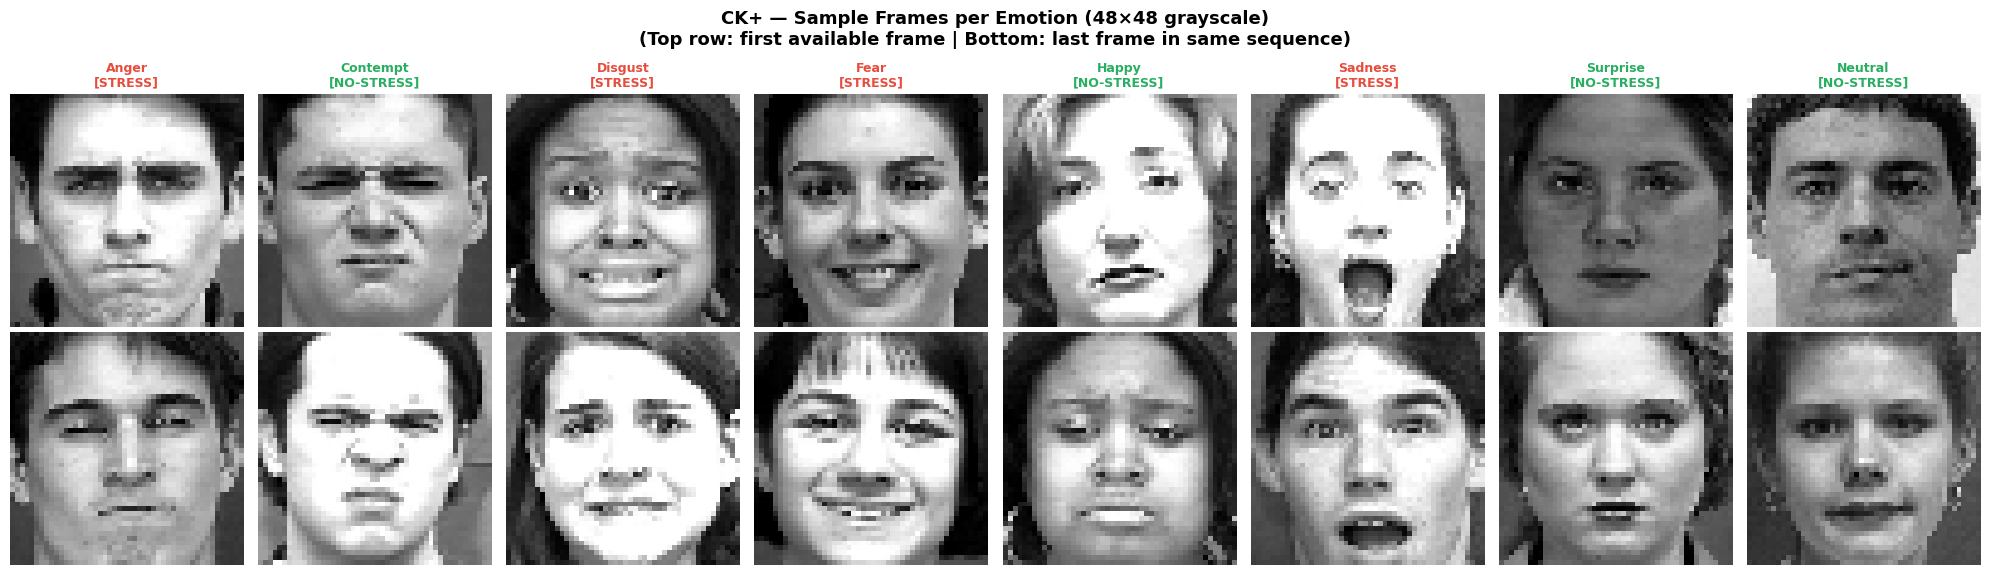

✅  CK+ sample grid saved!


In [ ]:
print("Preparing CK+ sample image grid...")

# Helper function to convert a pixel string to a displayable image
def parse_ck_pixels(pixel_string):
    """
    Takes a CK+ pixel string like '70 80 82 79 ...'
    Returns: a numpy array of shape (48, 48) with dtype uint8

    Steps:
      1. Split string by spaces → list of strings
      2. Convert each to float (some might be '70.0')
      3. Reshape 2304 values → 48×48 matrix
      4. Cast to uint8 (0–255 integer range)
    """
    pixel_list = pixel_string.split(' ')          # Step 1: split
    pixel_arr  = np.array(pixel_list, dtype=np.float32)  # Step 2: to float
    pixel_arr  = pixel_arr.reshape(48, 48)        # Step 3: reshape
    pixel_arr  = pixel_arr.astype(np.uint8)       # Step 4: to uint8
    return pixel_arr

# Show 2 samples per emotion (1 neutral/no-stress + 1 stress frame)
emotion_keys = sorted(CK_EMOTION_NAMES.keys())   # [0,1,2,3,4,5,6,7]

fig, axes = plt.subplots(2, len(emotion_keys), figsize=(20, 6))
fig.suptitle('CK+ — Sample Frames per Emotion (48×48 grayscale)\n'
             '(Top row: first available frame | Bottom: last frame in same sequence)',
             fontsize=13, fontweight='bold')

for col_idx, emotion_code in enumerate(emotion_keys):

    emotion_name = CK_EMOTION_NAMES[emotion_code]
    is_stress    = emotion_code in CK_STRESS_EMOTIONS
    colour       = '#e74c3c' if is_stress else '#27ae60'
    label_str    = 'STRESS' if is_stress else 'NO-STRESS'

    # Filter rows for this emotion
    emotion_rows = ck_df[ck_df['emotion'] == emotion_code]

    if len(emotion_rows) < 2:
        for row_idx in range(2):
            axes[row_idx][col_idx].axis('off')
            axes[row_idx][col_idx].set_title('Not enough\nsamples', fontsize=8)
        continue

    # Top row: first frame of the emotion sequence
    first_pixel_str = emotion_rows.iloc[0]['pixels']
    first_img       = parse_ck_pixels(first_pixel_str)

    axes[0][col_idx].imshow(first_img, cmap='gray')
    axes[0][col_idx].axis('off')
    axes[0][col_idx].set_title(f'{emotion_name}\n[{label_str}]',
                                fontsize=9, color=colour, fontweight='bold')

    # Bottom row: last frame of the emotion sequence (peak expression)
    last_pixel_str = emotion_rows.iloc[-1]['pixels']
    last_img       = parse_ck_pixels(last_pixel_str)

    axes[1][col_idx].imshow(last_img, cmap='gray')
    axes[1][col_idx].axis('off')

# Add row labels
axes[0][0].set_ylabel('First Frame', fontsize=11, fontweight='bold',
                       rotation=0, labelpad=55, va='center')
axes[1][0].set_ylabel('Last Frame\n(Peak)', fontsize=11, fontweight='bold',
                       rotation=0, labelpad=55, va='center')

plt.tight_layout()
plt.savefig('/content/ckplus_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  CK+ sample grid saved!")



Analysing pixel intensity distributions...


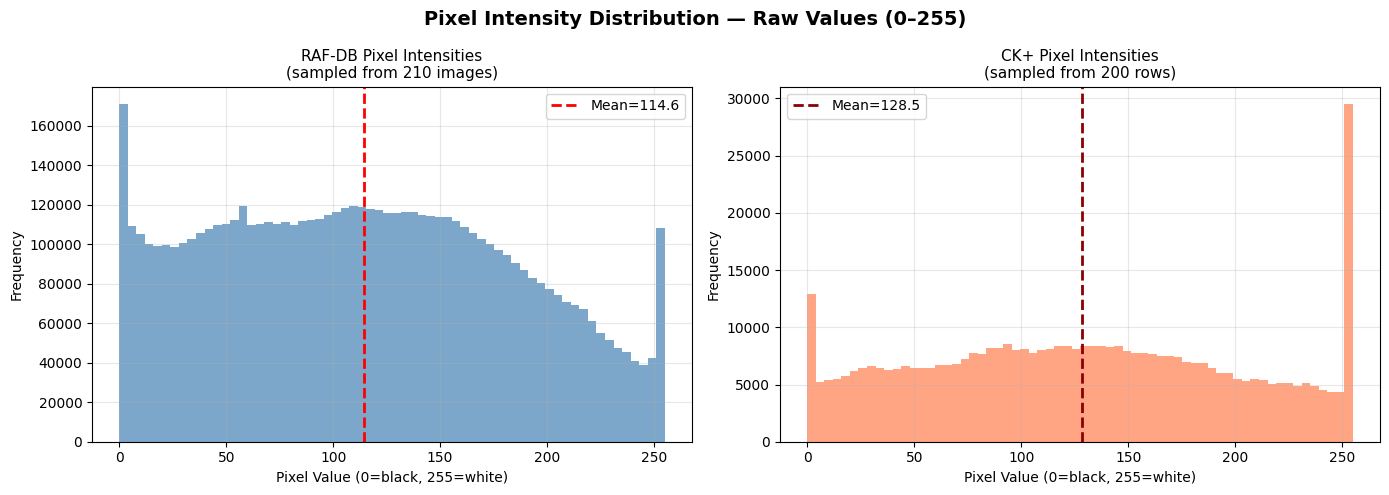

In [ ]:

print("Analysing pixel intensity distributions...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pixel Intensity Distribution — Raw Values (0–255)',
             fontsize=14, fontweight='bold')

# ── RAF-DB: Sample 200 random images, collect pixel values ───
raf_pixel_samples = []
sample_count = 0

for folder_num in ['1','2','3','4','5','6','7']:
    folder_path  = RAF_TRAIN_DIR / folder_num
    image_files  = list(folder_path.glob('*.jpg'))[:30]   # 30 per folder

    for img_path in image_files:
        img = cv2.imread(str(img_path))
        if img is not None:
            # .flatten() converts 2D/3D array to 1D list of all pixel values
            raf_pixel_samples.extend(img.flatten().tolist())
            sample_count += 1

# Plot RAF-DB histogram
axes[0].hist(raf_pixel_samples, bins=64, color='steelblue', alpha=0.7, edgecolor='none')
axes[0].set_title(f'RAF-DB Pixel Intensities\n(sampled from {sample_count} images)', fontsize=11)
axes[0].set_xlabel('Pixel Value (0=black, 255=white)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(raf_pixel_samples), color='red', linestyle='--',
                linewidth=2, label=f'Mean={np.mean(raf_pixel_samples):.1f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── CK+: Sample pixel values from the CSV ────────────────────
ck_pixel_samples = []

# Sample 200 rows from CK+ DataFrame
ck_sample_rows = ck_df.sample(min(200, len(ck_df)), random_state=SEED)

for _, row in ck_sample_rows.iterrows():
    try:
        pixels = parse_ck_pixels(row['pixels'])   # Our helper function from 6F
        ck_pixel_samples.extend(pixels.flatten().tolist())
    except Exception:
        pass   # Skip any malformed rows

# Plot CK+ histogram
axes[1].hist(ck_pixel_samples, bins=64, color='coral', alpha=0.7, edgecolor='none')
axes[1].set_title(f'CK+ Pixel Intensities\n(sampled from {len(ck_sample_rows)} rows)', fontsize=11)
axes[1].set_xlabel('Pixel Value (0=black, 255=white)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(ck_pixel_samples), color='darkred', linestyle='--',
                linewidth=2, label=f'Mean={np.mean(ck_pixel_samples):.1f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/pixel_intensity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(f"\n📊  RAF-DB Pixel Stats:")
print(f"    Mean  : {np.mean(raf_pixel_samples):.2f}")
print(f"    Std   : {np.std(raf_pixel_samples):.2f}")
print(f"    Min   : {np.min(raf_pixel_samples)}")
print(f"    Max   : {np.max(raf_pixel_samples)}")

print(f"\n📊  CK+ Pixel Stats:")
print(f"    Mean  : {np.mean(ck_pixel_samples):.2f}")
print(f"    Std   : {np.std(ck_pixel_samples):.2f}")
print(f"    Min   : {np.min(ck_pixel_samples)}")
print(f"    Max   : {np.max(ck_pixel_samples)}")
print("\n✅  Pixel distribution analysis complete!")
print("    Both datasets will be normalised to [0.0–1.0] during loading.")



📊  RAF-DB Pixel Stats:
    Mean  : 114.65
    Std   : 68.89
    Min   : 0
    Max   : 255

📊  CK+ Pixel Stats:
    Mean  : 128.48
    Std   : 73.85
    Min   : 0
    Max   : 255

✅  Pixel distribution analysis complete!
    Both datasets will be normalised to [0.0–1.0] during loading.


In [ ]:
print("=" * 60)
print("  📋  COMPLETE EDA SUMMARY")
print("=" * 60)

# ── RAF-DB summary ────────────────────────────────────────────
raf_train_total = raf_df[raf_df['Split'] == 'Train']['Image Count'].sum()
raf_test_total  = raf_df[raf_df['Split'] == 'Test']['Image Count'].sum()
raf_total       = raf_df['Image Count'].sum()

raf_stress_train    = raf_df[(raf_df['Split'] == 'Train') &
                              (raf_df['Label Name'] == 'STRESS')]['Image Count'].sum()
raf_nostress_train  = raf_df[(raf_df['Split'] == 'Train') &
                              (raf_df['Label Name'] == 'NO-STRESS')]['Image Count'].sum()

print(f"\n  🗂️   RAF-DB")
print(f"    Total Images      : {raf_total:,}")
print(f"    Training Set      : {raf_train_total:,}")
print(f"    Test Set          : {raf_test_total:,}")
print(f"    Train Stress      : {raf_stress_train:,}  ({raf_stress_train/raf_train_total*100:.1f}%)")
print(f"    Train No-Stress   : {raf_nostress_train:,}  ({raf_nostress_train/raf_train_total*100:.1f}%)")

# ── CK+ summary ───────────────────────────────────────────────
ck_total_frames   = len(ck_df)
ck_train_frames   = len(ck_df[ck_df['Usage'] == 'Training'])
ck_stress_frames  = len(ck_df[ck_df['emotion'].isin(CK_STRESS_EMOTIONS)])
ck_nostress_frames= ck_total_frames - ck_stress_frames

# Drop missing (important to do before loading!)
ck_df_clean = ck_df.dropna(subset=['pixels', 'emotion'])
dropped_rows = ck_total_frames - len(ck_df_clean)

print(f"\n  🗂️   CK+ (Extended)")
print(f"    Total Frames      : {ck_total_frames:,}")
print(f"    Training Frames   : {ck_train_frames:,}")
print(f"    Missing → Dropped : {dropped_rows}")
print(f"    Stress Frames     : {ck_stress_frames:,}  ({ck_stress_frames/ck_total_frames*100:.1f}%)")
print(f"    No-Stress Frames  : {ck_nostress_frames:,}  ({ck_nostress_frames/ck_total_frames*100:.1f}%)")


  📋  COMPLETE EDA SUMMARY

  🗂️   RAF-DB
    Total Images      : 15,339
    Training Set      : 12,271
    Test Set          : 3,068
    Train Stress      : 3,685  (30.0%)
    Train No-Stress   : 8,586  (70.0%)

  🗂️   CK+ (Extended)
    Total Frames      : 920
    Training Frames   : 734
    Missing → Dropped : 0
    Stress Frames     : 222  (24.1%)
    No-Stress Frames  : 698  (75.9%)


In [ ]:
# ── Class imbalance warning ───────────────────────────────────
# .query() — pandas way to filter with a string expression
stress_total    = raf_df.query('`Label Name` == "STRESS"')['Image Count'].sum() + ck_stress_frames
no_stress_total = raf_df.query('`Label Name` == "NO-STRESS"')['Image Count'].sum() + ck_nostress_frames
ratio           = max(stress_total, no_stress_total) / min(stress_total, no_stress_total)

print(f"\n  ⚖️   COMBINED CLASS BALANCE (estimated, before sequence filtering)")
print(f"    Stress (1)        : {stress_total:,}")
print(f"    No-Stress (0)     : {no_stress_total:,}")
print(f"    Imbalance Ratio   : {ratio:.2f}:1")

if ratio > 1.5:
    print(f"\n  ⚠️   CLASS IMBALANCE DETECTED (ratio > 1.5)")
    print(f"    Action: We will use class_weight in model.fit()")
    print(f"    This penalises the model more for missing the minority class.")
else:
    print(f"\n  ✅  Classes are reasonably balanced.")

print("\n" + "=" * 60)
print("  ✅  EDA COMPLETE — Ready to proceed to MediaPipe Alignment")
print("=" * 60)



  ⚖️   COMBINED CLASS BALANCE (estimated, before sequence filtering)
    Stress (1)        : 4,781
    No-Stress (0)     : 11,478
    Imbalance Ratio   : 2.40:1

  ⚠️   CLASS IMBALANCE DETECTED (ratio > 1.5)
    Action: We will use class_weight in model.fit()
    This penalises the model more for missing the minority class.

  ✅  EDA COMPLETE — Ready to proceed to MediaPipe Alignment
